In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA #principle component Analysis - Dimensity Reductions

In [8]:
data = {
    "message": [
        "Congratulations you won a lottery claim now",
        "Free entry in 2 lakh prize click here",
        "Call me when you are free",
        "Let's meet tomorrow",
        "Win cash now hurry up",
        "Are you coming to class today",
        "Limited offer buy now",
        "Hello bhai kya kar raha hai",
        "Earn money from home click now",
        "Assignment complete kiya kya",
        "Get free recharge now",
        "Kal milte hai library me",
        "Exclusive deal just for you",
        "Project submission kab hai",
        "Click here to win iPhone"
    ],
    "label": [
        "spam","spam","ham","ham","spam",
        "ham","spam","ham","spam","ham",
        "spam","ham","spam","ham","spam"
    ]
}

df = pd.DataFrame(data)
df.head()


,message,label
0,Congratulations you won a lottery claim now,spam
1,Free entry in 2 lakh prize click here,spam
2,Call me when you are free,ham
3,Let's meet tomorrow,ham
4,Win cash now hurry up,spam


In [9]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [12]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['message']).toarray()
y = df['label']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
model_linear = SVC(kernel='linear')
model_linear.fit(X_train, y_train)

model_rbf = SVC(kernel='rbf')
model_rbf.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [15]:
y_pred_linear = model_linear.predict(X_test)
y_pred_rbf = model_rbf.predict(X_test)

print("Linear Accuracy:", accuracy_score(y_test, y_pred_linear))
print("RBF Accuracy:", accuracy_score(y_test, y_pred_rbf))

Linear Accuracy: 1.0
RBF Accuracy: 0.3333333333333333


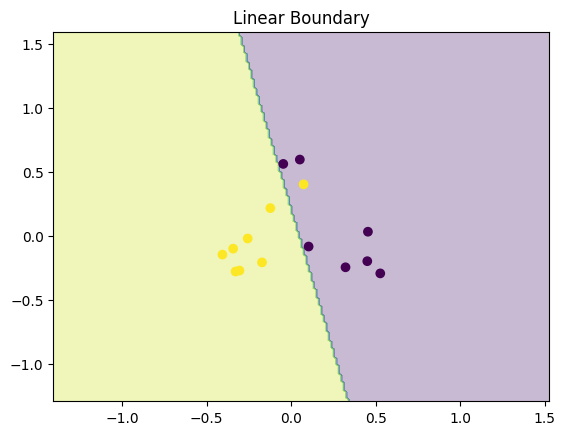

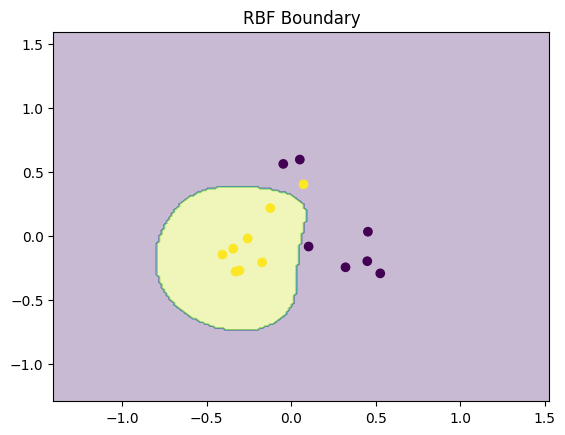

In [19]:
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

model_vis_linear = SVC(kernel='linear')
model_vis_linear.fit(X_reduced, y)

model_vis_rbf = SVC(kernel='rbf')
model_vis_rbf.fit(X_reduced, y)

def plot_decision_boundary(model, X, y, title):
    plt.figure()

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])#flatten
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y)

    plt.title(title)
    plt.show()

plot_decision_boundary(model_vis_linear, X_reduced, y, "Linear Boundary")
plot_decision_boundary(model_vis_rbf, X_reduced, y, "RBF Boundary")

In [ ]:
def predict_message(msg):
    msg_vector = vectorizer.transform([msg]).toarray()
    prediction = model_linear.predict(msg_vector)

    if prediction[0] == 1:
        print("Spam")
    else:
        print("Normal")

predict_message("Win money now click here")
predict_message("double your money in just 25 days")

Spam
Spam
